## Căn bằng lại dữ liệu train

In [1]:
import pandas as pd

In [11]:
df_train = pd.read_parquet("./Task_A/train.parquet")
df_final_test = pd.read_parquet("./Task_A/test_sample.parquet")
df_test = pd.read_parquet("./Task_A/test_sample.parquet")

In [3]:
# 2. Thống kê số lượng dòng cho mỗi giá trị trong cột 'language'
thong_ke = df_train['language'].value_counts()

# In kết quả
print(thong_ke)

language
Python    457306
C++        23392
Java       19302
Name: count, dtype: int64


In [4]:
thong_ke_1 = df_train['label'].value_counts()
print(thong_ke_1)

label
1    261525
0    238475
Name: count, dtype: int64


In [5]:

# Giả sử DataFrame của bạn tên là df, có chứa cột 'language' và 'label'

# 1. Đặt số lượng mục tiêu cho Python (ví dụ: lấy bằng mức của C++ là 23392)
target_size = 25000 

# 2. Tách dữ liệu thành 2 phần: Python và Các ngôn ngữ khác
df_python = df_train[df_train['language'] == 'Python']
df_others = df_train[df_train['language'] != 'Python']

# 3. Tính tỷ lệ dữ liệu cần giữ lại cho nhóm Python
fraction_to_keep = target_size / len(df_python)

# 4. Giảm số lượng Python nhưng giữ nguyên phân phối của cột 'label'
# Dùng groupby('label') và sample theo tỷ lệ frac
df_python_downsampled = df_python.groupby('label', group_keys=False).apply(
    lambda x: x.sample(frac=fraction_to_keep, random_state=42)
)

# 5. Gộp lại dữ liệu đã giảm với các ngôn ngữ khác
df_balanced = pd.concat([df_python_downsampled, df_others])

# 6. (Tuỳ chọn) Xáo trộn lại các dòng để dữ liệu không bị gom nhóm theo ngôn ngữ
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Kiểm tra lại kết quả
print("Số lượng theo ngôn ngữ sau khi giảm:")
print(df_balanced['language'].value_counts())

print("\nPhân phối label của Python sau khi giảm:")
print(df_balanced[df_balanced['language'] == 'Python']['label'].value_counts(normalize=True))

Số lượng theo ngôn ngữ sau khi giảm:
language
Python    25000
C++       23392
Java      19302
Name: count, dtype: int64

Phân phối label của Python sau khi giảm:
Series([], Name: proportion, dtype: float64)


## Trích xuất đặc trưng

In [12]:
df_final_test['line_count'] = df_final_test['code'].str.count('\n') + 1
df_final_test['len'] = df_final_test['code'].str.len()
# In kết quả
print(df_final_test[["line_count", "len"]].describe())

       line_count           len
count  1000.00000   1000.000000
mean     41.71800   1370.214000
std      45.40165   1565.786249
min       1.00000     43.000000
25%      14.00000    430.750000
50%      25.00000    848.000000
75%      51.25000   1627.750000
max     336.00000  12472.000000


In [15]:
# Lấy dòng có giá trị lớn nhất trong cột 'len'
longest_row = df_final_test.loc[df_final_test['len'].idxmax()]

# In kết quả
print(longest_row[["code", "label"]])

code     internal class ToolboxItemSnapLineBehavior : B...
label                                                    0
Name: 76, dtype: object


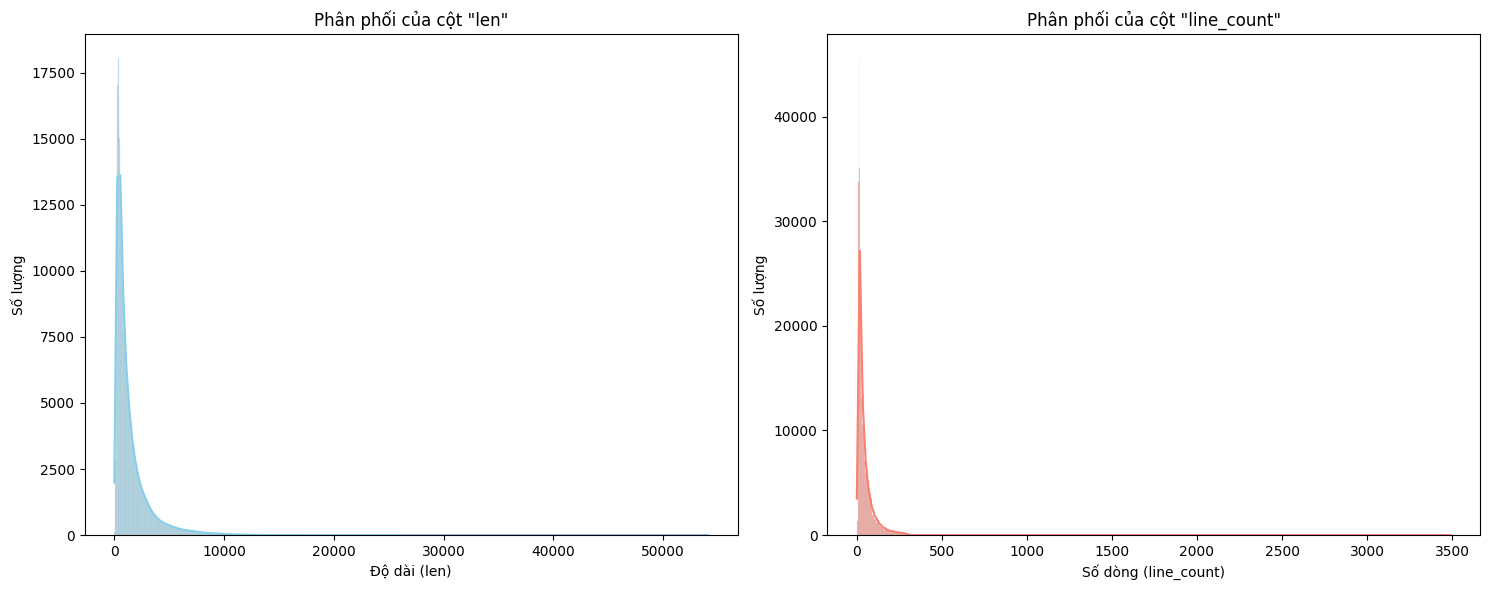

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử DataFrame của bạn là df

# Tạo một khung chứa 2 biểu đồ đặt cạnh nhau (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Vẽ phân phối cho cột 'len' (nằm ở ô bên trái)
sns.histplot(data=df_final_test, x='len', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Phân phối của cột "len"')
axes[0].set_xlabel('Độ dài (len)')
axes[0].set_ylabel('Số lượng')

# 2. Vẽ phân phối cho cột 'line_count' (nằm ở ô bên phải)
# line_count thường là số nguyên nên có thể dùng discrete=True nếu số lượng giá trị ít
sns.histplot(data=df_final_test, x='line_count', kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Phân phối của cột "line_count"')
axes[1].set_xlabel('Số dòng (line_count)')
axes[1].set_ylabel('Số lượng')

# Hiển thị biểu đồ không bị lẹm chữ
plt.tight_layout()
plt.show()

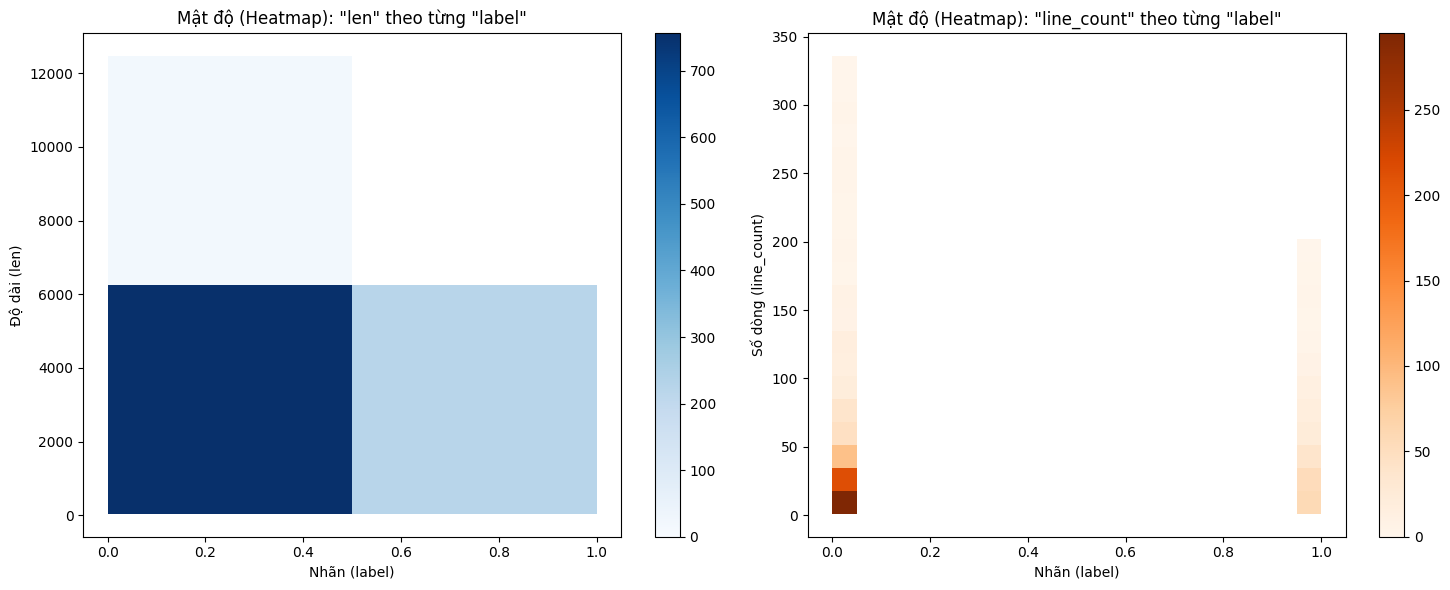

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử DataFrame của bạn tên là df

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Biểu đồ Heatmap (2D Hist) giữa label (0,1) và len
# discrete=(True, False) tức là: trục X rời rạc, trục Y liên tục
sns.histplot(data=df_final_test, x='label', y='len', discrete=(True, False), cbar=True, cmap='Blues', ax=axes[0])
axes[0].set_xticks([0, 1]) # Ép trục X chỉ hiển thị số 0 và 1
axes[0].set_title('Mật độ Heatmap: "len" theo "label"')
axes[0].set_xlabel('Nhãn (label)')
axes[0].set_ylabel('Độ dài (len)')

# 2. Biểu đồ Heatmap (2D Hist) giữa label (0,1) và line_count
# Nếu line_count cũng là số nguyên rời rạc, bạn có thể dùng discrete=(True, True)
sns.histplot(data=df_final_test, x='label', y='line_count', discrete=(True, True), cbar=True, cmap='Oranges', ax=axes[1])
axes[1].set_xticks([0, 1]) # Ép trục X chỉ hiển thị số 0 và 1
axes[1].set_title('Mật độ Heatmap: "line_count" theo "label"')
axes[1].set_xlabel('Nhãn (label)')
axes[1].set_ylabel('Số dòng (line_count)')

# Căn chỉnh và hiển thị
plt.tight_layout()
plt.show()